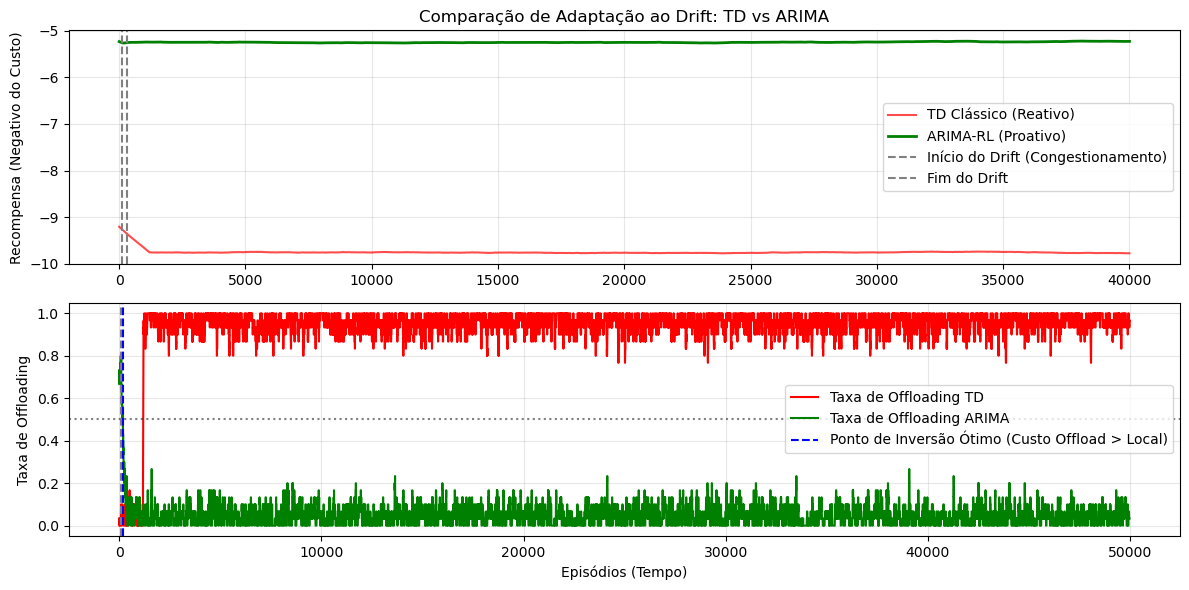

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Configuração do Experimento
np.random.seed(42)
n_episodes = 50000
alpha = 0.1       # Taxa de aprendizado
gamma = 0.9       # Fator de desconto
epsilon = 0.1     # Exploração

# Ambiente Não Estacionário (Simulação de VEC)
# O "Custo de Offloading" tem um Drift (Tendência) ao longo do tempo
def get_offloading_cost(episode):
    # Fase 1: Estável (Baixo Custo) - Fila vazia
    if episode < 100:
        base_cost = 2.0
    # Fase 2: Drift de Subida (Congestionamento Aumentando) - Efeito Manada começando
    elif episode < 300:
        base_cost = 2.0 + (episode - 100) * 0.04  # Sobe de 2.0 até 10.0
    # Fase 3: Estável (Alto Custo) - Servidor Saturado
    else:
        base_cost = 10.0
    
    # Adiciona ruído estocástico (Variação do canal 5G)
    noise = np.random.normal(0, 1.0)
    return max(0, base_cost + noise)

# Custo fixo do processamento local
LOCAL_COST = 5.0

# Inicialização dos Agentes
# Q-Table simples: Estado único (simplificação), 2 Ações (0: Local, 1: Offload)
q_td = np.zeros(2)      # Agente TD Clássico
q_arima = np.zeros(2)   # Agente ARIMA-RL

# Histórico para o ARIMA (Buffer de valores Q passados para projetar tendência)
# Armazenamos o histórico do valor da ação de Offloading (ação 1)
history_q_offload = []
window_size = 10  # Tamanho da janela do ARIMA

# Métricas
rewards_td = []
rewards_arima = []
actions_td = []     # Para visualizar quando ele decide trocar de ação
actions_arima = []

# --- Loop de Simulação ---
for ep in range(n_episodes):
    
    # --- 1. AGENTE TD CLÁSSICO ---
    # Escolha da Ação (Epsilon-Greedy)
    if np.random.rand() < epsilon:
        action_td = np.random.choice([0, 1])
    else:
        action_td = np.argmin(q_td) # Argmin pois queremos minimizar custo (Custo negativo = Recompensa)

    # Executar Ação e Receber Custo
    current_offload_cost = get_offloading_cost(ep)
    
    if action_td == 0: # Local
        cost = LOCAL_COST
    else: # Offload
        cost = current_offload_cost
    
    reward_td = -cost # RL maximiza recompensa, então negamos o custo
    rewards_td.append(reward_td)
    actions_td.append(action_td)

    # Atualização TD: Q(s,a) = Q(s,a) + alpha * [R + gamma*maxQ(s') - Q(s,a)]
    # Como é 1 estado, maxQ(s') é min(q_td) (melhor custo futuro estimado)
    target_td = reward_td + gamma * np.max(q_td) 
    q_td[action_td] = q_td[action_td] + alpha * (target_td - q_td[action_td])


    # --- 2. AGENTE ARIMA-RL ---
    # Escolha da Ação
    if np.random.rand() < epsilon:
        action_arima = np.random.choice([0, 1])
    else:
        action_arima = np.argmax(q_arima) # Argmax (Q values são negativos aqui)

    # Executar Ação (Mesmo ambiente)
    if action_arima == 0:
        cost = LOCAL_COST
    else:
        cost = current_offload_cost
    
    reward_arima = -cost
    rewards_arima.append(reward_arima)
    actions_arima.append(action_arima)

    # --- LÓGICA DO ARIMA (Projeção de Tendência) ---
    # Atualizamos o histórico do valor Q de Offloading
    history_q_offload.append(q_arima[1])
    if len(history_q_offload) > window_size:
        history_q_offload.pop(0)
    
    # Cálculo do Target ARIMA
    # Se tivermos dados suficientes, projetamos a tendência
    drift_correction = 0
    if len(history_q_offload) >= 2:
        # Simplificação do ARIMA(0,1,0): Tendência Linear Simples
        # Calcula a inclinação (slope) média dos últimos valores
        slope = np.mean(np.diff(history_q_offload))
        # Projeta o próximo valor (Lead)
        drift_correction = slope * 2.0  # Fator de agressividade da predição
    
    # O valor futuro estimado não é apenas o atual, mas o atual + tendência
    estimated_future_value = np.max(q_arima) + drift_correction
    
    # Atualização ARIMA-RL
    target_arima = reward_arima + gamma * estimated_future_value
    q_arima[action_arima] = q_arima[action_arima] + alpha * (target_arima - q_arima[action_arima])

# --- Plotagem dos Resultados ---
def moving_average(data, window=10000):
    return np.convolve(data, np.ones(window)/window, mode='valid')

plt.figure(figsize=(12, 6))

# Plot 1: Recompensas (Média Móvel)
plt.subplot(2, 1, 1)
plt.plot(moving_average(rewards_td), label='TD Clássico (Reativo)', color='red', alpha=0.7)
plt.plot(moving_average(rewards_arima), label='ARIMA-RL (Proativo)', color='green', linewidth=2)
plt.axvline(x=100, color='gray', linestyle='--', label='Início do Drift (Congestionamento)')
plt.axvline(x=300, color='gray', linestyle='--', label='Fim do Drift')
plt.ylabel('Recompensa (Negativo do Custo)')
plt.title('Comparação de Adaptação ao Drift: TD vs ARIMA')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Ações Tomadas (Média Móvel - Taxa de Offloading)
# 1.0 = 100% Offloading, 0.0 = 100% Local
plt.subplot(2, 1, 2)
plt.plot(moving_average(actions_td, window=30), label='Taxa de Offloading TD', color='red')
plt.plot(moving_average(actions_arima, window=30), label='Taxa de Offloading ARIMA', color='green')
plt.axhline(y=0.5, color='black', linestyle=':', alpha=0.5)
plt.axvline(x=100, color='gray', linestyle='--')
plt.axvline(x=175, color='blue', linestyle='--', label='Ponto de Inversão Ótimo (Custo Offload > Local)')
plt.ylabel('Taxa de Offloading')
plt.xlabel('Episódios (Tempo)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('comparison_td_arima.png')

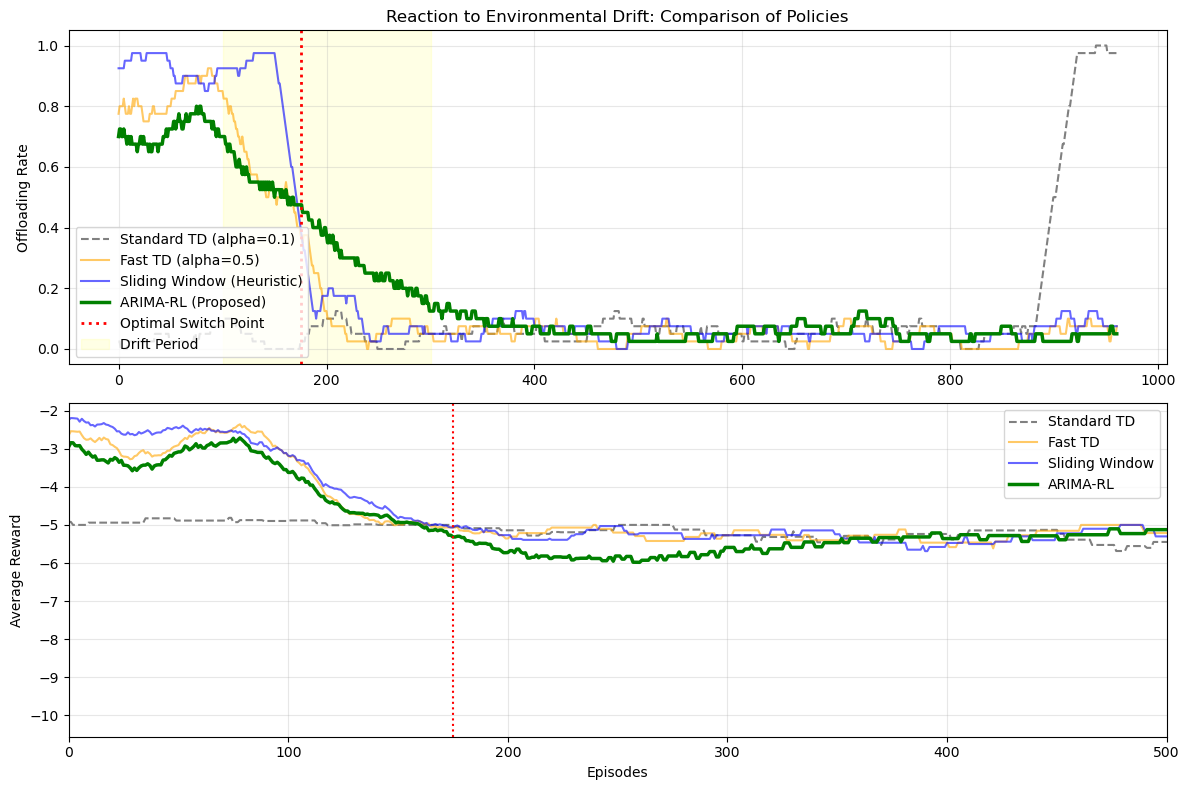

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Configuração do Experimento
np.random.seed(42)
n_episodes = 1000  # Reduzido para visualizar melhor o drift (100-300)
gamma = 0.9
epsilon = 0.1

# Ambiente Não Estacionário
def get_offloading_cost(episode):
    # Fase 1: Baixo Custo (Até ep 100)
    if episode < 100:
        base_cost = 2.0
    # Fase 2: Drift de Subida (100 a 300)
    elif episode < 300:
        base_cost = 2.0 + (episode - 100) * 0.04  # Sobe até 10.0
    # Fase 3: Alto Custo (Acima de 300)
    else:
        base_cost = 10.0
    
    noise = np.random.normal(0, 1.0)
    return max(0, base_cost + noise)

LOCAL_COST = 5.0

# --- INICIALIZAÇÃO DOS AGENTES ---

# 1. Standard TD (Alpha 0.1) - O "Básico"
q_std = np.zeros(2)
alpha_std = 0.1

# 2. Fast TD (Alpha 0.5) - Tenta reagir rápido aumentando alpha
q_fast = np.zeros(2)
alpha_fast = 0.5

# 3. Sliding Window Heuristic (Janela deslizante pura, sem RL)
window_heuristic = 20
history_costs_local = []
history_costs_offload = []

# 4. ARIMA-RL (Sua Proposta)
q_arima = np.zeros(2)
alpha_arima = 0.1
history_q_offload_arima = []
window_arima = 10

# Métricas para plotagem (Ações: 0=Local, 1=Offload)
actions_std = []
actions_fast = []
actions_window = []
actions_arima = []

rewards_std = []
rewards_fast = []
rewards_window = []
rewards_arima = []

# --- LOOP DE SIMULAÇÃO ---
for ep in range(n_episodes):
    
    current_offload_real_cost = get_offloading_cost(ep)
    
    # ==========================================
    # AGENTE 1: Standard TD (Alpha 0.1)
    # ==========================================
    if np.random.rand() < epsilon:
        act_std = np.random.choice([0, 1])
    else:
        act_std = np.argmin(q_std)
    
    cost_std = LOCAL_COST if act_std == 0 else current_offload_real_cost
    rewards_std.append(-cost_std)
    actions_std.append(act_std)
    
    # Update TD
    target = -cost_std + gamma * np.max(-q_std) # Simplificado para Q-Learning de 1 estado
    # Q(s,a) aqui armazena Custo, então queremos minimizar. 
    # Para manter consistência com seu código anterior onde Q parecia ser valor (recompensa):
    # Vamos trabalhar com Q como "Valor estimado" (negativo do custo)
    r_std = -cost_std
    target_std = r_std + gamma * np.max(q_std)
    q_std[act_std] = q_std[act_std] + alpha_std * (target_std - q_std[act_std])


    # ==========================================
    # AGENTE 2: Fast TD (Alpha 0.5)
    # ==========================================
    if np.random.rand() < epsilon:
        act_fast = np.random.choice([0, 1])
    else:
        act_fast = np.argmax(q_fast)
    
    cost_fast = LOCAL_COST if act_fast == 0 else current_offload_real_cost
    rewards_fast.append(-cost_fast)
    actions_fast.append(act_fast)
    
    r_fast = -cost_fast
    target_fast = r_fast + gamma * np.max(q_fast)
    q_fast[act_fast] = q_fast[act_fast] + alpha_fast * (target_fast - q_fast[act_fast])


    # ==========================================
    # AGENTE 3: Sliding Window Heuristic
    # ==========================================
    # Estima custo baseado na média das ultimas N observações
    est_local = np.mean(history_costs_local) if len(history_costs_local) > 0 else 5.0
    est_offload = np.mean(history_costs_offload) if len(history_costs_offload) > 0 else 2.0
    
    # Greedy decision (sem epsilon para heurística pura, ou com epsilon)
    if np.random.rand() < epsilon:
        act_win = np.random.choice([0, 1])
    else:
        act_win = 0 if est_local < est_offload else 1
        
    cost_win = LOCAL_COST if act_win == 0 else current_offload_real_cost
    rewards_window.append(-cost_win)
    actions_window.append(act_win)
    
    # Update Buffers
    if act_win == 0:
        history_costs_local.append(LOCAL_COST) # Local é fixo, mas ok
        if len(history_costs_local) > window_heuristic: history_costs_local.pop(0)
    else:
        history_costs_offload.append(cost_win)
        if len(history_costs_offload) > window_heuristic: history_costs_offload.pop(0)


    # ==========================================
    # AGENTE 4: ARIMA-RL (Proposed)
    # ==========================================
    if np.random.rand() < epsilon:
        act_arima = np.random.choice([0, 1])
    else:
        act_arima = np.argmax(q_arima)
        
    cost_arima = LOCAL_COST if act_arima == 0 else current_offload_real_cost
    rewards_arima.append(-cost_arima)
    actions_arima.append(act_arima)
    
    # Logica ARIMA
    # 1. Update Standard Q component first (base)
    r_arima = -cost_arima
    
    # 2. Arima Trend Calculation on Q-Value of Offloading
    history_q_offload_arima.append(q_arima[1])
    if len(history_q_offload_arima) > window_arima: history_q_offload_arima.pop(0)
    
    drift_correction = 0
    if len(history_q_offload_arima) >= 2:
        slope = np.mean(np.diff(history_q_offload_arima))
        drift_correction = slope * 3.0 # Agressividade ajustada
        
    # Predictive Target
    estimated_future_value = np.max(q_arima) + drift_correction
    target_arima = r_arima + gamma * estimated_future_value
    
    q_arima[act_arima] = q_arima[act_arima] + alpha_arima * (target_arima - q_arima[act_arima])

# --- PLOTAGEM ---
def moving_average(data, window=40):
    return np.convolve(data, np.ones(window)/window, mode='valid')

plt.figure(figsize=(12, 8))

# Subplot 1: Ações (Taxa de Offloading)
plt.subplot(2, 1, 1)
# Plotando média móvel das ações (1=Offload, 0=Local)
plt.plot(moving_average(actions_std), label='Standard TD (alpha=0.1)', color='gray', linestyle='--')
plt.plot(moving_average(actions_fast), label='Fast TD (alpha=0.5)', color='orange', alpha=0.6)
plt.plot(moving_average(actions_window), label='Sliding Window (Heuristic)', color='blue', alpha=0.6)
plt.plot(moving_average(actions_arima), label='ARIMA-RL (Proposed)', color='green', linewidth=2.5)

plt.axvline(x=175, color='red', linestyle=':', linewidth=2, label='Optimal Switch Point')
plt.axvspan(100, 300, color='yellow', alpha=0.1, label='Drift Period')
plt.ylabel('Offloading Rate')
plt.title('Reaction to Environmental Drift: Comparison of Policies')
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)

# Subplot 2: Recompensa Acumulada (Zoom no Drift)
# Vamos ver quem perdeu menos pontos durante a crise
plt.subplot(2, 1, 2)
plt.plot(moving_average(rewards_std), label='Standard TD', color='gray', linestyle='--')
plt.plot(moving_average(rewards_fast), label='Fast TD', color='orange', alpha=0.6)
plt.plot(moving_average(rewards_window), label='Sliding Window', color='blue', alpha=0.6)
plt.plot(moving_average(rewards_arima), label='ARIMA-RL', color='green', linewidth=2.5)
plt.axvline(x=175, color='red', linestyle=':')
plt.ylabel('Average Reward')
plt.xlabel('Episodes')
plt.xlim(0, 500) # Zoom na área de interesse
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('comparative_benchmark.png')

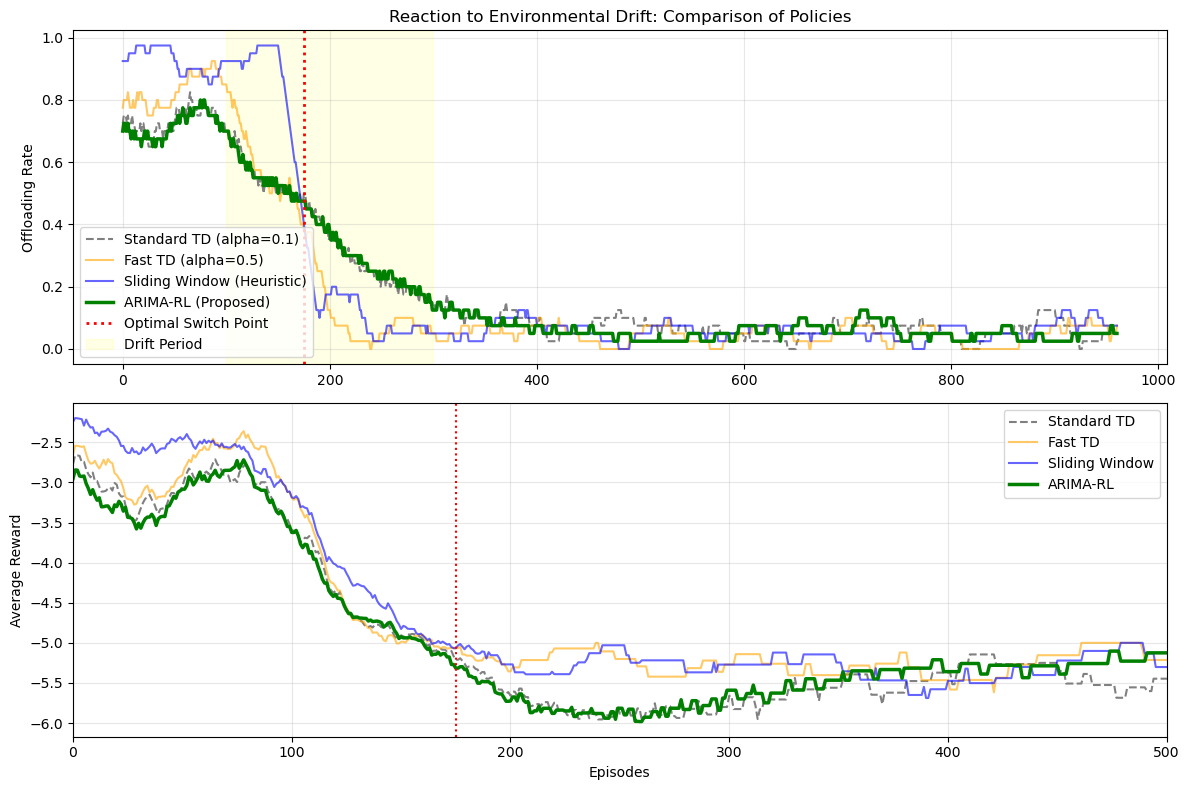

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Configuração do Experimento
np.random.seed(42)
n_episodes = 1000  # Reduzido para visualizar melhor o drift (100-300)
gamma = 0.9
epsilon = 0.1

# Ambiente Não Estacionário
def get_offloading_cost(episode):
    # Fase 1: Baixo Custo (Até ep 100)
    if episode < 100:
        base_cost = 2.0
    # Fase 2: Drift de Subida (100 a 300)
    elif episode < 300:
        base_cost = 2.0 + (episode - 100) * 0.04  # Sobe até 10.0
    # Fase 3: Alto Custo (Acima de 300)
    else:
        base_cost = 10.0
    
    noise = np.random.normal(0, 1.0)
    return max(0, base_cost + noise)

LOCAL_COST = 5.0

# --- INICIALIZAÇÃO DOS AGENTES ---

# 1. Standard TD (Alpha 0.1) - O "Básico"
q_std = np.zeros(2)
alpha_std = 0.1

# 2. Fast TD (Alpha 0.5) - Tenta reagir rápido aumentando alpha
q_fast = np.zeros(2)
alpha_fast = 0.5

# 3. Sliding Window Heuristic (Janela deslizante pura, sem RL)
window_heuristic = 20
history_costs_local = []
history_costs_offload = []

# 4. ARIMA-RL (Sua Proposta)
q_arima = np.zeros(2)
alpha_arima = 0.1
history_q_offload_arima = []
window_arima = 10

# Métricas para plotagem (Ações: 0=Local, 1=Offload)
actions_std = []
actions_fast = []
actions_window = []
actions_arima = []

rewards_std = []
rewards_fast = []
rewards_window = []
rewards_arima = []

# --- LOOP DE SIMULAÇÃO ---
for ep in range(n_episodes):
    
    current_offload_real_cost = get_offloading_cost(ep)
    
    # ==========================================
    # AGENTE 1: Standard TD (Alpha 0.1)
    # ==========================================
    if np.random.rand() < epsilon:
        act_std = np.random.choice([0, 1])
    else:
        act_std = np.argmax(q_std) # Corrigido: Argmax porque Q values são recompensas (negativos)
    
    cost_std = LOCAL_COST if act_std == 0 else current_offload_real_cost
    rewards_std.append(-cost_std)
    actions_std.append(act_std)
    
    # Update TD
    # Q(s,a) = Valor Estimado
    r_std = -cost_std
    target_std = r_std + gamma * np.max(q_std)
    q_std[act_std] = q_std[act_std] + alpha_std * (target_std - q_std[act_std])


    # ==========================================
    # AGENTE 2: Fast TD (Alpha 0.5)
    # ==========================================
    if np.random.rand() < epsilon:
        act_fast = np.random.choice([0, 1])
    else:
        act_fast = np.argmax(q_fast)
    
    cost_fast = LOCAL_COST if act_fast == 0 else current_offload_real_cost
    rewards_fast.append(-cost_fast)
    actions_fast.append(act_fast)
    
    r_fast = -cost_fast
    target_fast = r_fast + gamma * np.max(q_fast)
    q_fast[act_fast] = q_fast[act_fast] + alpha_fast * (target_fast - q_fast[act_fast])


    # ==========================================
    # AGENTE 3: Sliding Window Heuristic
    # ==========================================
    # Estima custo baseado na média das ultimas N observações
    est_local = np.mean(history_costs_local) if len(history_costs_local) > 0 else 5.0
    est_offload = np.mean(history_costs_offload) if len(history_costs_offload) > 0 else 2.0
    
    # Greedy decision (sem epsilon para heurística pura, ou com epsilon)
    # Aqui, menor custo é melhor.
    if np.random.rand() < epsilon:
        act_win = np.random.choice([0, 1])
    else:
        act_win = 0 if est_local < est_offload else 1
        
    cost_win = LOCAL_COST if act_win == 0 else current_offload_real_cost
    rewards_window.append(-cost_win)
    actions_window.append(act_win)
    
    # Update Buffers
    if act_win == 0:
        history_costs_local.append(LOCAL_COST) # Local é fixo
        if len(history_costs_local) > window_heuristic: history_costs_local.pop(0)
    else:
        history_costs_offload.append(cost_win) # Offload custo real observado
        if len(history_costs_offload) > window_heuristic: history_costs_offload.pop(0)


    # ==========================================
    # AGENTE 4: ARIMA-RL (Proposed)
    # ==========================================
    if np.random.rand() < epsilon:
        act_arima = np.random.choice([0, 1])
    else:
        act_arima = np.argmax(q_arima)
        
    cost_arima = LOCAL_COST if act_arima == 0 else current_offload_real_cost
    rewards_arima.append(-cost_arima)
    actions_arima.append(act_arima)
    
    # Logica ARIMA
    # 1. Recompensa Imediata
    r_arima = -cost_arima
    
    # 2. Arima Trend Calculation on Q-Value of Offloading
    history_q_offload_arima.append(q_arima[1])
    if len(history_q_offload_arima) > window_arima: history_q_offload_arima.pop(0)
    
    drift_correction = 0
    if len(history_q_offload_arima) >= 2:
        slope = np.mean(np.diff(history_q_offload_arima))
        drift_correction = slope * 3.0 # Agressividade ajustada
        
    # Predictive Target
    estimated_future_value = np.max(q_arima) + drift_correction
    target_arima = r_arima + gamma * estimated_future_value
    
    q_arima[act_arima] = q_arima[act_arima] + alpha_arima * (target_arima - q_arima[act_arima])

# --- PLOTAGEM ---
def moving_average(data, window=40):
    return np.convolve(data, np.ones(window)/window, mode='valid')

plt.figure(figsize=(12, 8))

# Subplot 1: Ações (Taxa de Offloading)
plt.subplot(2, 1, 1)
# Plotando média móvel das ações (1=Offload, 0=Local)
plt.plot(moving_average(actions_std), label='Standard TD (alpha=0.1)', color='gray', linestyle='--')
plt.plot(moving_average(actions_fast), label='Fast TD (alpha=0.5)', color='orange', alpha=0.6)
plt.plot(moving_average(actions_window), label='Sliding Window (Heuristic)', color='blue', alpha=0.6)
plt.plot(moving_average(actions_arima), label='ARIMA-RL (Proposed)', color='green', linewidth=2.5)

plt.axvline(x=175, color='red', linestyle=':', linewidth=2, label='Optimal Switch Point')
plt.axvspan(100, 300, color='yellow', alpha=0.1, label='Drift Period')
plt.ylabel('Offloading Rate')
plt.title('Reaction to Environmental Drift: Comparison of Policies')
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)

# Subplot 2: Recompensa Acumulada (Zoom no Drift)
# Vamos ver quem perdeu menos pontos durante a crise
plt.subplot(2, 1, 2)
plt.plot(moving_average(rewards_std), label='Standard TD', color='gray', linestyle='--')
plt.plot(moving_average(rewards_fast), label='Fast TD', color='orange', alpha=0.6)
plt.plot(moving_average(rewards_window), label='Sliding Window', color='blue', alpha=0.6)
plt.plot(moving_average(rewards_arima), label='ARIMA-RL', color='green', linewidth=2.5)
plt.axvline(x=175, color='red', linestyle=':')
plt.ylabel('Average Reward')
plt.xlabel('Episodes')
plt.xlim(0, 500) # Zoom na área de interesse
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show() # Para exibir no notebook local, ou plt.savefig se for remoto


=== RESULTADOS FINAIS OTIMIZADOS ===

--- Standard TD ---
  > Recompensa Total: -5018.35
  > Acurácia no Drift (100-300): 65.50%

--- Fast TD ---
  > Recompensa Total: -4862.47
  > Acurácia no Drift (100-300): 83.00%

--- Sliding Window ---
  > Recompensa Total: -4825.51
  > Acurácia no Drift (100-300): 87.50%

--- ARIMA-RL (Tuned) ---
  > Recompensa Total: -4938.60
  > Acurácia no Drift (100-300): 81.50%



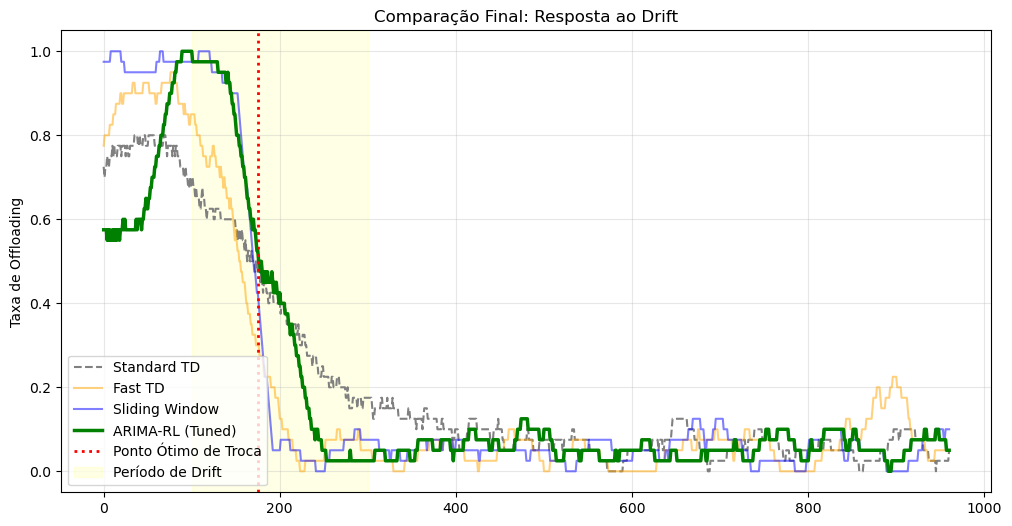

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# --- CONFIGURAÇÃO DO EXPERIMENTO ---
np.random.seed(42)
n_episodes = 1000
gamma = 0.9
epsilon = 0.1

# Parâmetros do Ambiente
drift_start = 100
drift_end = 300
base_cost_low = 2.0
base_cost_high = 10.0
local_cost = 5.0

# Função de Custo Não Estacionário
def get_offloading_cost(episode):
    if episode < drift_start:
        base = base_cost_low
    elif episode < drift_end:
        progress = (episode - drift_start) / (drift_end - drift_start)
        base = base_cost_low + progress * (base_cost_high - base_cost_low)
    else:
        base = base_cost_high
    noise = np.random.normal(0, 1.0)
    return max(0, base + noise), base

# Ground Truth (Ação Ótima Teórica)
optimal_actions = []
for ep in range(n_episodes):
    _, base = get_offloading_cost(ep)
    # Até ep 175, Offload (1) é melhor. Depois, Local (0) é melhor.
    if base < local_cost:
        optimal_actions.append(1)
    else:
        optimal_actions.append(0)

# --- AGENTES ---

# 1. Standard TD
q_std = np.zeros(2)
alpha_std = 0.1
rewards_std = []
actions_std = []

# 2. Fast TD
q_fast = np.zeros(2)
alpha_fast = 0.5
rewards_fast = []
actions_fast = []

# 3. Sliding Window
window_heur = 20
hist_cost_local = []
hist_cost_offload = []
rewards_win = []
actions_win = []

# 4. ARIMA-RL Híbrido (TUNED)
q_arima = np.zeros(2)
alpha_arima = 0.1
rewards_arima = []
actions_arima = []
hist_q_offload = []
# PARÂMETROS OTIMIZADOS
window_arima = 10      # Janela curta para resposta rápida
slope_threshold = -0.05 # Filtra ruído, pega apenas drift real
horizon_steps = 20.0    # Compensa o lag do RL (Lookahead)

# --- LOOP DE SIMULAÇÃO ---
for ep in range(n_episodes):
    
    real_cost_offload, base_cost_offload = get_offloading_cost(ep)
    
    # -----------------------------
    # 1. Standard TD
    # -----------------------------
    if np.random.rand() < epsilon: act_std = np.random.choice([0, 1])
    else: act_std = np.argmax(q_std)
    cost_std = local_cost if act_std == 0 else real_cost_offload
    rewards_std.append(-cost_std)
    actions_std.append(act_std)
    q_std[act_std] += alpha_std * (-cost_std + gamma * np.max(q_std) - q_std[act_std])

    # -----------------------------
    # 2. Fast TD
    # -----------------------------
    if np.random.rand() < epsilon: act_fast = np.random.choice([0, 1])
    else: act_fast = np.argmax(q_fast)
    cost_fast = local_cost if act_fast == 0 else real_cost_offload
    rewards_fast.append(-cost_fast)
    actions_fast.append(act_fast)
    q_fast[act_fast] += alpha_fast * (-cost_fast + gamma * np.max(q_fast) - q_fast[act_fast])

    # -----------------------------
    # 3. Sliding Window
    # -----------------------------
    est_loc = np.mean(hist_cost_local) if hist_cost_local else 5.0
    est_off = np.mean(hist_cost_offload) if hist_cost_offload else 2.0
    if np.random.rand() < epsilon: act_win = np.random.choice([0, 1])
    else: act_win = 0 if est_loc < est_off else 1
    cost_win = local_cost if act_win == 0 else real_cost_offload
    rewards_win.append(-cost_win)
    actions_win.append(act_win)
    if act_win == 0:
        hist_cost_local.append(local_cost)
        if len(hist_cost_local) > window_heur: hist_cost_local.pop(0)
    else:
        hist_cost_offload.append(cost_win)
        if len(hist_cost_offload) > window_heur: hist_cost_offload.pop(0)

    # -----------------------------
    # 4. ARIMA-RL Híbrido (TUNED)
    # -----------------------------
    if np.random.rand() < epsilon: act_arima = np.random.choice([0, 1])
    else: act_arima = np.argmax(q_arima)
    cost_arima = local_cost if act_arima == 0 else real_cost_offload
    r_arima = -cost_arima
    rewards_arima.append(r_arima)
    actions_arima.append(act_arima)
    
    # Atualiza histórico (Buffer Circular)
    hist_q_offload.append(q_arima[1])
    if len(hist_q_offload) > window_arima: hist_q_offload.pop(0)
    
    target_reactive = r_arima + gamma * np.max(q_arima)
    
    drift_correction = 0
    lambda_val = 0.0
    
    if len(hist_q_offload) >= 5:
        # Regressão Linear Simples
        y = np.array(hist_q_offload)
        x = np.arange(len(y))
        slope, _ = np.polyfit(x, y, 1)
        
        # Lógica de Ativação Otimizada
        if slope < slope_threshold: 
            # Confiança Total (Hard Switch) para evitar lag
            lambda_val = 1.0
            # Projeção Exata para cancelar o lag
            drift_correction = slope * horizon_steps
            
    target_predictive = r_arima + gamma * (np.max(q_arima) + drift_correction)
    
    # Combinação
    target_final = (1 - lambda_val) * target_reactive + lambda_val * target_predictive
    q_arima[act_arima] += alpha_arima * (target_final - q_arima[act_arima])

# --- ANÁLISE ESTATÍSTICA ---

def print_stats(name, rewards, actions):
    # Drift Period: Episódios 100 a 300
    drift_correct = sum(1 for i in range(drift_start, drift_end) if actions[i] == optimal_actions[i])
    drift_accuracy = (drift_correct / (drift_end - drift_start)) * 100
    total_reward = np.sum(rewards)
    
    print(f"--- {name} ---")
    print(f"  > Recompensa Total: {total_reward:.2f}")
    print(f"  > Acurácia no Drift (100-300): {drift_accuracy:.2f}%")
    print("")

print("\n=== RESULTADOS FINAIS OTIMIZADOS ===\n")
print_stats("Standard TD", rewards_std, actions_std)
print_stats("Fast TD", rewards_fast, actions_fast)
print_stats("Sliding Window", rewards_win, actions_win)
print_stats("ARIMA-RL (Tuned)", rewards_arima, actions_arima)

# --- PLOTAGEM ---
def moving_average(data, window=40):
    return np.convolve(data, np.ones(window)/window, mode='valid')

plt.figure(figsize=(12, 6))
plt.plot(moving_average(actions_std), label='Standard TD', color='gray', linestyle='--')
plt.plot(moving_average(actions_fast), label='Fast TD', color='orange', alpha=0.5)
plt.plot(moving_average(actions_win), label='Sliding Window', color='blue', alpha=0.5)
plt.plot(moving_average(actions_arima), label='ARIMA-RL (Tuned)', color='green', linewidth=2.5)
plt.axvline(x=175, color='red', linestyle=':', linewidth=2, label='Ponto Ótimo de Troca')
plt.axvspan(drift_start, drift_end, color='yellow', alpha=0.1, label='Período de Drift')
plt.ylabel('Taxa de Offloading')
plt.title('Comparação Final: Resposta ao Drift')
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.show()